# 05: Feature Engineering
This notebook prepares the cleaned UNSW-NB15 dataset for modelling by removing low-value features, encoding categorical variables, applying log transformations to skewed distributions, and standardising numeric features.

## 5.1: Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Prevent truncation of long column values in displayed DataFrames
pd.set_option('display.max_colwidth', None)

# Set a white grid background for all plots
sns.set_style('whitegrid')

## 5.2: Load CSV File

In [2]:
# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/UNSW-NB15.csv', low_memory=False)

In [3]:
df.head()

,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,udp,CON,0.001055,132,164,31,29,0,0,dns,...,0.0,3,7,1,3,1,1,1,Normal,0
1,udp,CON,0.036133,528,304,31,29,0,0,unidentified,...,0.0,2,4,2,3,1,1,2,Normal,0
2,udp,CON,0.001119,146,178,31,29,0,0,dns,...,0.0,12,8,1,2,2,1,1,Normal,0
3,udp,CON,0.001209,132,164,31,29,0,0,dns,...,0.0,6,9,1,1,1,1,1,Normal,0
4,udp,CON,0.001169,146,178,31,29,0,0,dns,...,0.0,7,9,1,1,1,1,1,Normal,0


## 5.3: Drop Weak Predictors

Features with a Kendall tau correlation below |τ| = 0.05 with the `Label` column offer minimal predictive signal and are removed to reduce noise and dimensionality. These thresholds were identified in `04_eda.ipynb`. The Kendall tau threshold is set conservatively at 0.05 rather than the typical Pearson cutoff because Kendall tau values are inherently smaller in magnitude — roughly two-thirds of the equivalent Pearson coefficient — making 0.05 a meaningful signal boundary for this measure.

In [4]:
# Features with |τ| < 0.05 with Label, as identified in 04_eda.ipynb
WEAK_PREDICTORS = [
    'is_sm_ips_ports',  # τ = -0.0016
    'smeansz',          # τ = -0.0044
    'res_bdy_len',      # τ =  0.0076
    'is_ftp_login',     # τ = -0.0116
    'Djit',             # τ =  0.0211
    'ct_ftp_cmd',       # τ =  0.0230
    'dur',              # τ =  0.0281
    'Sload',            # τ = -0.0401
    'ct_dst_src_ltm',   # τ =  0.0421
    'ct_srv_src',       # τ = -0.0449
    'Dintpkt',          # τ =  0.0459
    'dwin',             # τ = -0.0477
    'swin',             # τ = -0.0483
]

df.drop(columns=WEAK_PREDICTORS, inplace=True)
print(f'Dropped {len(WEAK_PREDICTORS)} weak predictors.')
print(f'Remaining columns: {df.shape[1]}')

Dropped 13 weak predictors.
Remaining columns: 27


## 5.4: Drop Redundant Features

Feature pairs with a Kendall tau correlation above |τ| = 0.9 with each other are near-duplicates — retaining both adds no new information and inflates dimensionality. For each redundant pair, the feature with the weaker absolute correlation to `Label` is removed. Where both members of a pair were already removed as weak predictors, no additional action is needed.

In [5]:
# For each high-correlation pair (|τ| > 0.9 with each other), the feature with the lower
# absolute correlation to Label is dropped. Pairs where both features were already removed
# as weak predictors (is_ftp_login/ct_ftp_cmd, swin/dwin) are not listed here.
REDUNDANT_FEATURES = [
    'ct_flw_http_mthd', # Pair: trans_depth (τ=0.997); trans_depth kept (equal |τ| with Label, listed first)
    'dloss',            # Pair: Dpkts (τ=0.938); Dpkts kept (|τ|=0.147 > 0.118)
    'Spkts',            # Pair: Dpkts (τ=0.930); Dpkts kept (|τ|=0.147 > 0.109)
    'sttl',             # Pair: ct_state_ttl (τ=0.903); ct_state_ttl kept (|τ|=0.832 > 0.768)
]

df.drop(columns=REDUNDANT_FEATURES, inplace=True)
print(f'Dropped {len(REDUNDANT_FEATURES)} redundant features.')
print(f'Remaining columns: {df.shape[1]}')

Dropped 4 redundant features.
Remaining columns: 23


## 5.5: Engineer New Features

Five new features are derived from existing numeric columns to capture interaction patterns that no single raw feature can express. All are computed from raw values before log-transformation and standardisation, so they will automatically be picked up by both those steps.

| Feature | Formula | NIDS relevance |
|---|---|---|
| `bytes_ratio` | `sbytes / (sbytes + dbytes + 1)` | Traffic asymmetry — scanning and DoS tend to be heavily one-directional |
| `total_bytes` | `sbytes + dbytes` | Overall session size; large values can indicate data exfiltration |
| `bytes_per_dpkt` | `sbytes / (Dpkts + 1)` | Bytes sent per received packet — high = large requests, tiny responses (amplification) |
| `tcp_setup_time` | `synack + ackdat` | Total TCP handshake duration; anomalous values signal spoofing or SYN floods |
| `loss_rate` | `sloss / (Dpkts + 1)` | Approximate drop ratio — elevated under flooding and scanning |

In [6]:
# Traffic direction asymmetry: proportion of total bytes originating from the source
# High values indicate one-sided flows common in scanning and DoS
df['bytes_ratio'] = df['sbytes'] / (df['sbytes'] + df['dbytes'] + 1)

# Total session volume: combined byte count in both directions
df['total_bytes'] = df['sbytes'] + df['dbytes']

# Payload size asymmetry: source bytes per destination packet received
# High values suggest large requests with small responses (e.g. amplification attacks)
df['bytes_per_dpkt'] = df['sbytes'] / (df['Dpkts'] + 1)

# TCP handshake duration: sum of SYN-ACK and ACK timings
# Unusual values can indicate SYN floods or TCP spoofing
df['tcp_setup_time'] = df['synack'] + df['ackdat']

# Approximate loss rate: source packet losses relative to destination packet count
# Elevated values are common in flooding and scanning
df['loss_rate'] = df['sloss'] / (df['Dpkts'] + 1)

print(f'Engineered 5 new features. Total columns: {df.shape[1]}')
df[['bytes_ratio', 'total_bytes', 'bytes_per_dpkt', 'tcp_setup_time', 'loss_rate']].describe().round(4)

Engineered 5 new features. Total columns: 28


,bytes_ratio,total_bytes,bytes_per_dpkt,tcp_setup_time,loss_rate
count,2.024469e+06,2.024469e+06,2.024469e+06,2.024469e+06,2.024469e+06
mean,3.748000e-01,4.777695e+04,1.575459e+02,7.400000e-03,1.491000e-01
std,2.805000e-01,1.846952e+05,4.685507e+02,5.090000e-02,1.966000e-01
min,0.000000e+00,4.600000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.900000e-02,8.720000e+02,4.866670e+01,0.000000e+00,0.000000e+00
50%,4.396000e-01,9.202000e+03,5.984620e+01,6.000000e-04,1.373000e-01
75%,5.584000e-01,3.009400e+04,1.004746e+02,7.000000e-04,2.105000e-01
max,1.000000e+00,1.472823e+07,5.494400e+04,1.003750e+01,2.100000e+01


## 5.5.1: Validate Engineered Features — Correlation with Label and Existing Features

Before proceeding, each engineered feature is validated on two criteria using Kendall tau (consistent with the approach in `04_eda.ipynb`):

1. **Predictive signal**: |τ| with `Label` must exceed 0.05. Features below this threshold offer minimal signal and should be dropped rather than carried forward.
2. **Non-redundancy**: |τ| with any existing feature must remain below 0.9. A value at or above this threshold indicates the engineered feature is near-duplicating information already in the dataset and should be dropped.

Correlations are computed on the pre-encoded dataset so that the raw numeric relationships are captured without artefacts introduced by encoding or transformation.

=== Correlation with Label ===


,τ (with Label),|τ|,Passes signal (|τ| ≥ 0.05)
bytes_ratio,0.1868,0.1868,True
total_bytes,-0.1242,0.1242,True
bytes_per_dpkt,0.1464,0.1464,True
tcp_setup_time,0.0970,0.0970,True
loss_rate,0.0264,0.0264,False



=== Redundancy Check (|τ| ≥ 0.9 with any existing feature) ===


,Engineered Feature,Correlated With,τ
0,tcp_setup_time,synack,0.9066


ACTION REQUIRED: consider dropping the flagged engineered feature(s).


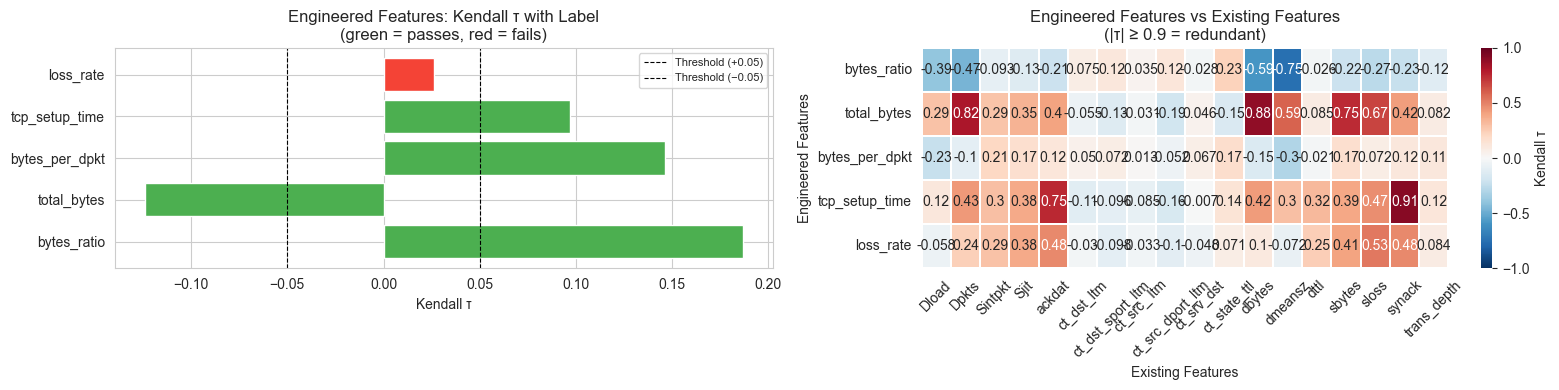

In [7]:
ENGINEERED_FEATURES = ['bytes_ratio', 'total_bytes', 'bytes_per_dpkt', 'tcp_setup_time', 'loss_rate']

# Only numeric columns can be passed to Kendall tau; exclude categorical and target columns
existing_numeric = df.select_dtypes(include=[np.number]).columns.difference(
    ENGINEERED_FEATURES + ['Label', 'attack_cat']
).tolist()

# Correlation with Label
label_tau = df[ENGINEERED_FEATURES + ['Label']].corr(method='kendall')['Label'].drop('Label')

label_summary = pd.DataFrame({
    'τ (with Label)':  label_tau.round(4),
    '|τ|':             label_tau.abs().round(4),
    'Passes signal (|τ| ≥ 0.05)': label_tau.abs() >= 0.05,
})
print('=== Correlation with Label ===')
display(label_summary)

# Correlation with existing numeric features
corr_matrix = df[ENGINEERED_FEATURES + existing_numeric].corr(method='kendall')
eng_vs_existing = corr_matrix.loc[ENGINEERED_FEATURES, existing_numeric]

# Flag pairs that exceed the redundancy threshold
REDUNDANCY_THRESHOLD = 0.9
redundant_pairs = []
for feat in ENGINEERED_FEATURES:
    for col in existing_numeric:
        tau_val = eng_vs_existing.loc[feat, col]
        if abs(tau_val) >= REDUNDANCY_THRESHOLD:
            redundant_pairs.append({'Engineered Feature': feat, 'Correlated With': col, 'τ': round(tau_val, 4)})

print(f'\n=== Redundancy Check (|τ| ≥ {REDUNDANCY_THRESHOLD} with any existing feature) ===')
if redundant_pairs:
    display(pd.DataFrame(redundant_pairs))
    print('ACTION REQUIRED: consider dropping the flagged engineered feature(s).')
else:
    print('No engineered feature is redundant with any existing feature.')

# Heatmap: engineered features vs existing numeric features
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: correlation with Label (bar chart)
colours = ['#4CAF50' if v else '#F44336' for v in label_summary['Passes signal (|τ| ≥ 0.05)']]
axes[0].barh(label_summary.index, label_summary['τ (with Label)'], color=colours)
axes[0].axvline(x=0.05,  color='black', linewidth=0.8, linestyle='--', label='Threshold (+0.05)')
axes[0].axvline(x=-0.05, color='black', linewidth=0.8, linestyle='--', label='Threshold (−0.05)')
axes[0].set_title('Engineered Features: Kendall τ with Label\n(green = passes, red = fails)')
axes[0].set_xlabel('Kendall τ')
axes[0].legend(fontsize=8)

# Right: heatmap vs existing numeric features
sns.heatmap(
    eng_vs_existing,
    ax=axes[1],
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    linewidths=0.3,
    cbar_kws={'label': 'Kendall τ'}
)
axes[1].set_title(f'Engineered Features vs Existing Features\n(|τ| ≥ {REDUNDANCY_THRESHOLD} = redundant)')
axes[1].set_xlabel('Existing Features')
axes[1].set_ylabel('Engineered Features')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# Remove redundant engineered features
REDUNDANT_ENGINEERED_FEATURES = ['loss_rate', 'tcp_setup_time']

df.drop(columns=REDUNDANT_ENGINEERED_FEATURES, inplace=True)
print(f'Dropped {len(REDUNDANT_ENGINEERED_FEATURES)} redundant engineered features.')
print(f'Remaining columns: {df.shape[1]}')

Dropped 2 redundant engineered features.
Remaining columns: 26


## 5.6: Encode Categorical Features

Machine learning models require numeric inputs. The three remaining categorical features — `proto`, `state`, and `service` — must be encoded before modelling. The encoding strategy is chosen based on each feature's cardinality as identified in `04_eda.ipynb`. The multi-class target `attack_cat` is also encoded as an ordered integer label so that it can be used directly by classifiers.

### 5.6.1: Protocol

`proto` has 135 unique values (High cardinality), making one-hot encoding impractical — it would produce 134 sparse binary columns. Frequency encoding replaces each protocol label with its proportion of occurrences in the dataset, preserving information about how common each protocol is while maintaining a single numeric column.

In [9]:
# Replace each protocol string with its relative frequency in the dataset
proto_frequency = df['proto'].value_counts(normalize=True)
df['proto'] = df['proto'].map(proto_frequency)

print('Protocol frequency encoding applied.')
print(f'proto dtype: {df["proto"].dtype}')
df['proto'].describe()

Protocol frequency encoding applied.
proto dtype: float64


count    2.024469e+06
mean     5.881276e-01
std      2.028971e-01
min      4.939567e-07
25%      2.767155e-01
50%      7.152261e-01
75%      7.152261e-01
max      7.152261e-01
Name: proto, dtype: float64

### 5.6.2: State

`state` has 14 unique values (Low cardinality) with no natural ordering, making one-hot encoding appropriate. The first dummy column is dropped to avoid perfect multicollinearity (the dummy variable trap). Column names are prefixed with `state_` to avoid ambiguity.

In [10]:
# One-hot encode state with drop_first=True to avoid the dummy variable trap
state_dummies = pd.get_dummies(df['state'], prefix='state', drop_first=True, dtype=int)
df = pd.concat([df.drop(columns=['state']), state_dummies], axis=1)

print(f'State one-hot encoded: {state_dummies.shape[1]} columns added')
print(f'Columns added: {state_dummies.columns.tolist()}')

State one-hot encoded: 13 columns added
Columns added: ['state_CLO', 'state_CON', 'state_ECO', 'state_ECR', 'state_FIN', 'state_INT', 'state_MAS', 'state_PAR', 'state_REQ', 'state_RST', 'state_TST', 'state_TXD', 'state_URN']


### 5.6.3: Service

`service` has 13 unique values (Low cardinality) and follows the same encoding strategy as `state`. One-hot encoding is applied with the first dummy dropped and columns prefixed with `service_`.

In [11]:
# One-hot encode service with drop_first=True to avoid the dummy variable trap
service_dummies = pd.get_dummies(df['service'], prefix='service', drop_first=True, dtype=int)
df = pd.concat([df.drop(columns=['service']), service_dummies], axis=1)

print(f'Service one-hot encoded: {service_dummies.shape[1]} columns added')
print(f'Columns added: {service_dummies.columns.tolist()}')

Service one-hot encoded: 12 columns added
Columns added: ['service_dns', 'service_ftp', 'service_ftp-data', 'service_http', 'service_irc', 'service_pop3', 'service_radius', 'service_smtp', 'service_snmp', 'service_ssh', 'service_ssl', 'service_unidentified']


### 5.6.4: Attack Category

`attack_cat` is the multi-class target variable. It is label-encoded to assign each attack category a unique integer, making it usable by classifiers. The mapping is stored and displayed to preserve interpretability.

In [12]:
# Label-encode attack_cat and store the category-to-integer mapping
category_codes = pd.CategoricalDtype(categories=sorted(df['attack_cat'].unique()), ordered=False)
df['attack_cat'] = df['attack_cat'].astype(category_codes).cat.codes

# Display the mapping for reference
attack_cat_mapping = pd.DataFrame({
    'Category': sorted(category_codes.categories),
    'Code': range(len(category_codes.categories))
})
print('attack_cat label encoding:')
display(attack_cat_mapping)

attack_cat label encoding:


,Category,Code
0,Analysis,0
1,Backdoor,1
2,DoS,2
3,Exploits,3
4,Fuzzers,4
5,Generic,5
6,Normal,6
7,Reconnaissance,7
8,Shellcode,8
9,Worms,9


## 5.7: Log-Transform Skewed Features

Many numeric features in this dataset exhibit strong right skew, as seen in the histograms in `04_eda.ipynb`. Highly skewed distributions can impair gradient-based and distance-based models by compressing the majority of values near zero while allowing extreme outliers to dominate. A log1p transformation (log(1 + x)) compresses the long tail, making distributions more symmetric while safely handling zero values. The transformation is applied to all continuous numeric features with a skewness coefficient greater than 1.

In [13]:
# Identify continuous numeric features (excluding binary Label, encoded attack_cat, and one-hot dummies)
exclude_from_transform = ['Label', 'attack_cat'] + state_dummies.columns.tolist() + service_dummies.columns.tolist()
continuous_features = df.select_dtypes(include=[np.number]).columns.difference(exclude_from_transform).tolist()

# Compute skewness for each continuous feature
skewness = df[continuous_features].skew().sort_values(ascending=False)
skewness_summary = pd.DataFrame({
    'Skewness': skewness.round(3),
    'Apply log1p': skewness.abs() > 1
})
print(f'Continuous features assessed: {len(continuous_features)}')
display(skewness_summary)

Continuous features assessed: 22


,Skewness,Apply log1p
trans_depth,143.372,True
sbytes,129.928,True
sloss,110.846,True
Sjit,56.886,True
ackdat,39.571,True
synack,37.497,True
bytes_per_dpkt,32.083,True
Sintpkt,28.781,True
ct_dst_sport_ltm,12.459,True
total_bytes,12.192,True


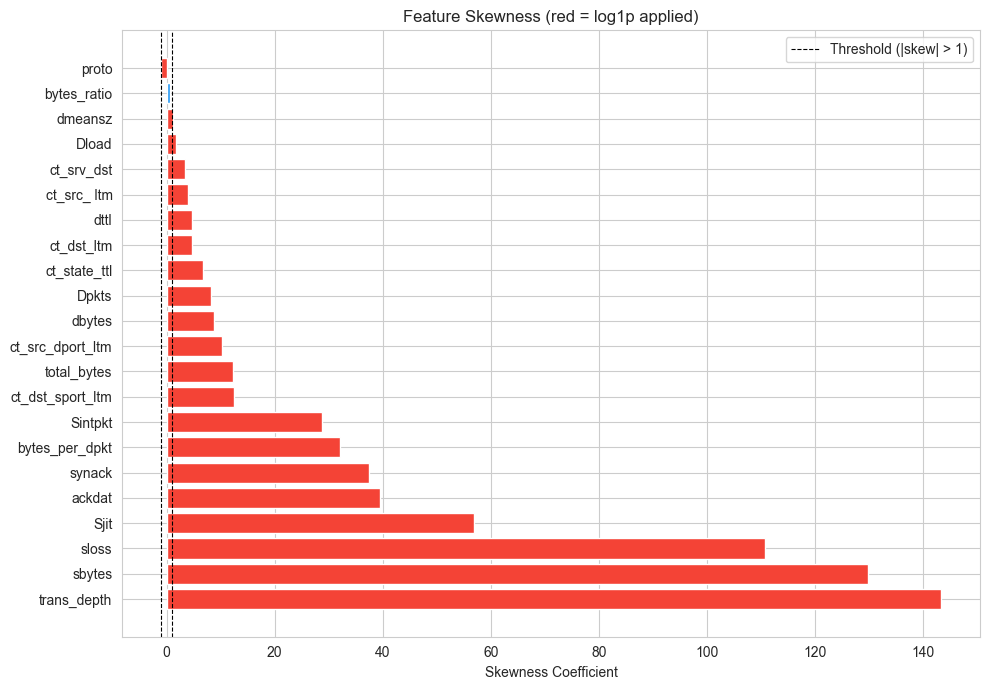

In [14]:
# Visualise skewness values to identify features that require transformation
fig, ax = plt.subplots(figsize=(10, 7))

colours = ['#F44336' if abs(v) > 1 else '#2196F3' for v in skewness.values]
ax.barh(skewness.index, skewness.values, color=colours)
ax.axvline(x=1, color='black', linewidth=0.8, linestyle='--', label='Threshold (|skew| > 1)')
ax.axvline(x=-1, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Skewness (red = log1p applied)')
ax.set_xlabel('Skewness Coefficient')
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# Apply log1p to features with |skewness| > 1
skewed_features = skewness[skewness.abs() > 1].index.tolist()
df[skewed_features] = df[skewed_features].apply(np.log1p)

print(f'log1p applied to {len(skewed_features)} features:')
print(skewed_features)

log1p applied to 21 features:
['trans_depth', 'sbytes', 'sloss', 'Sjit', 'ackdat', 'synack', 'bytes_per_dpkt', 'Sintpkt', 'ct_dst_sport_ltm', 'total_bytes', 'ct_src_dport_ltm', 'dbytes', 'Dpkts', 'ct_state_ttl', 'ct_dst_ltm', 'dttl', 'ct_src_ ltm', 'ct_srv_dst', 'Dload', 'dmeansz', 'proto']


## 5.8: Train-Test Split

The dataset is split into training and test sets before standardisation to prevent data leakage — if the scaler were fit on the full dataset, test set statistics would influence the training data transform, giving an optimistic and unreliable estimate of model performance. An 80/20 split is used with stratification on `Label` to preserve the original 87:13 class ratio in both sets. A fixed random seed ensures reproducibility.

In [16]:
# Split into train (80%) and test (20%), stratified on the binary label
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)

# Reset indices for clean downstream indexing
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train records: {len(train_df):,}')
print(f'Test records:  {len(test_df):,}')

Train records: 1,619,575
Test records:  404,894


In [17]:
# Verify that class proportions are preserved in both splits
train_dist = train_df['Label'].value_counts(normalize=True).rename('Train %')
test_dist = test_df['Label'].value_counts(normalize=True).rename('Test %')
split_summary = pd.concat([train_dist, test_dist], axis=1).mul(100).round(2)
split_summary.index = ['Normal (0)', 'Attack (1)']
display(split_summary)

,Train %,Test %
Normal (0),95.63,95.63
Attack (1),4.37,4.37


## 5.9: Resample Training Set

The original dataset is heavily imbalanced — 87.2% normal traffic versus 12.8% attack — which would bias a model toward predicting normal and suppressing attack detection. Two resampling strategies are applied to the training set only; the test set is left untouched to reflect realistic deployment conditions.

**Attack category balancing:** Each attack category is capped at 15,000 records (random undersampling). Minimum floors use a tiered scheme based on each category's original size, to limit the duplication ratio introduced by random oversampling:

| Category | Floor |
|---|---|
| Worms | 1,000 |
| Backdoor | 2,000 |
| Shellcode | 3,000 |
| Analysis | 4,000 |
| All others | 5,000 |

This prevents dominant categories such as Generic from overwhelming the others while keeping duplication ratios manageable for rare categories (e.g. Worms: ~7x rather than ~29x). Note that oversampling of rare categories still introduces duplicate records, which can cause overfitting — this is a known trade-off of random oversampling.

**Normal-to-attack ratio:** After attack categories are balanced, normal traffic is undersampled to achieve a **3:1 ratio** (normal:attack). This ratio was chosen as a middle ground within the target range of 2:1 to 5:1 — it substantially reduces the dominance of normal traffic while still reflecting that legitimate traffic is more prevalent than attacks in real networks.

In [18]:
# Downsample categories above this count
ATTACK_CAT_MAX = 15_000

NORMAL_TO_ATTACK_RATIO = 3

# Per-category minimums — rare categories use lower floors to limit duplication ratios
ATTACK_CAT_MIN = {
    'Worms':     1_000,
    'Backdoor':  2_000,
    'Shellcode': 3_000,
    'Analysis':  4_000,
}

# Applies to all other attack categories
ATTACK_CAT_DEFAULT_MIN = 5_000

# Build a code → min mapping using attack_cat_mapping from section 5.6.4
cat_min_map = {
    row['Code']: ATTACK_CAT_MIN.get(row['Category'], ATTACK_CAT_DEFAULT_MIN)
    for _, row in attack_cat_mapping.iterrows()
}

# Separate normal and attack records in the training set
train_normal = train_df[train_df['Label'] == 0]
train_attack = train_df[train_df['Label'] == 1]

# Show the attack category distribution before resampling, using readable category names
before_counts = train_attack['attack_cat'].value_counts().sort_index()
before_named = before_counts.rename(index=dict(zip(attack_cat_mapping['Code'], attack_cat_mapping['Category'])))
print('Attack category counts before resampling:')
print(before_named.to_string())

Attack category counts before resampling:
attack_cat
Analysis           1602
Backdoor           1503
DoS                4383
Exploits          21938
Fuzzers           16793
Generic           15121
Reconnaissance     8067
Shellcode          1164
Worms               139


In [19]:
# Resample each attack category to be within [cat_min, ATTACK_CAT_MAX]
resampled_categories = []
for cat_code in sorted(train_attack['attack_cat'].unique()):
    cat_df = train_attack[train_attack['attack_cat'] == cat_code]
    n = len(cat_df)
    cat_min = cat_min_map[cat_code]
    if n > ATTACK_CAT_MAX:
        cat_resampled = resample(cat_df, replace=False, n_samples=ATTACK_CAT_MAX, random_state=42)
    elif n < cat_min:
        cat_resampled = resample(cat_df, replace=True, n_samples=cat_min, random_state=42)
    else:
        cat_resampled = cat_df
    resampled_categories.append(cat_resampled)

train_attack_resampled = pd.concat(resampled_categories)

# Undersample normal traffic to achieve the target normal:attack ratio
target_normal_count = NORMAL_TO_ATTACK_RATIO * len(train_attack_resampled)
train_normal_resampled = resample(
    train_normal,
    replace=False,
    n_samples=min(target_normal_count, len(train_normal)),
    random_state=42
)

# Combine and shuffle the resampled training set
train_df = (
    pd.concat([train_normal_resampled, train_attack_resampled])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

actual_ratio = (train_df['Label'] == 0).sum() / (train_df['Label'] == 1).sum()
print(f'Train records after resampling: {len(train_df):,}')
print(f'Normal: {(train_df["Label"] == 0).sum():,}')
print(f'Attack: {(train_df["Label"] == 1).sum():,}')
print(f'Normal:Attack ratio = {actual_ratio:.2f}:1')

Train records after resampling: 272,268
Normal: 204,201
Attack: 68,067
Normal:Attack ratio = 3.00:1


Attack category counts before vs after resampling:


,Before,After
attack_cat,,
Analysis,1602,4000
Backdoor,1503,2000
DoS,4383,5000
Exploits,21938,15000
Fuzzers,16793,15000
Generic,15121,15000
Reconnaissance,8067,8067
Shellcode,1164,3000
Worms,139,1000


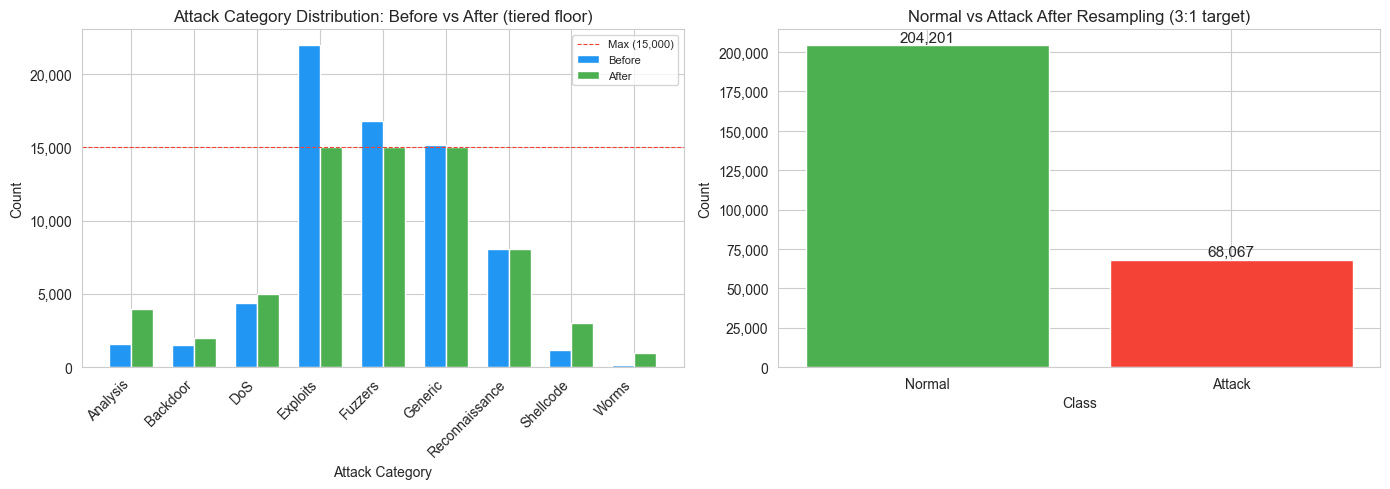

In [20]:
# Compare attack category counts before and after resampling
after_counts = train_df[train_df['Label'] == 1]['attack_cat'].value_counts().sort_index()
after_named = after_counts.rename(index=dict(zip(attack_cat_mapping['Code'], attack_cat_mapping['Category'])))

comparison = pd.DataFrame({
    'Before': before_named,
    'After': after_named
}).fillna(0).astype(int)
print('Attack category counts before vs after resampling:')
display(comparison)

# Bar chart comparing before and after attack category distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = comparison.index.tolist()
x = range(len(categories))
width = 0.35

axes[0].bar([i - width / 2 for i in x], comparison['Before'], width, color='#2196F3', label='Before')
axes[0].bar([i + width / 2 for i in x], comparison['After'], width, color='#4CAF50', label='After')
axes[0].set_title('Attack Category Distribution: Before vs After (tiered floor)')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('Count')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(categories, rotation=45, ha='right')
axes[0].axhline(y=ATTACK_CAT_MAX, color='#F44336', linewidth=0.8, linestyle='--', label=f'Max ({ATTACK_CAT_MAX:,})')
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

label_counts_after = train_df['Label'].value_counts()
axes[1].bar(['Normal', 'Attack'], label_counts_after.values, color=['#4CAF50', '#F44336'])
axes[1].set_title(f'Normal vs Attack After Resampling ({NORMAL_TO_ATTACK_RATIO}:1 target)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
for bar, count in zip(axes[1].patches, label_counts_after.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{count:,}',
        ha='center', va='bottom', fontsize=11
    )

plt.tight_layout()
plt.show()

## 5.10: Standardise Numeric Features

Standardisation rescales each continuous numeric feature to have zero mean and unit variance. This ensures that features with large numeric ranges do not dominate distance-based or regularised models. The scaler parameters (mean and standard deviation) are derived from the training set only and then applied to both sets — fitting on the test set would constitute data leakage. One-hot encoded dummy columns (already 0/1) and target columns (`Label`, `attack_cat`) are excluded from standardisation.

In [21]:
# Fit scaler parameters on training data only to prevent data leakage
train_mean = train_df[continuous_features].mean()
train_std = train_df[continuous_features].std()

# Apply the same transform to both splits
train_df[continuous_features] = (train_df[continuous_features] - train_mean) / train_std
test_df[continuous_features] = (test_df[continuous_features] - train_mean) / train_std

print(f'Standardised {len(continuous_features)} continuous features (fit on train only).')
train_df[continuous_features].describe().loc[['mean', 'std']].round(6)

Standardised 22 continuous features (fit on train only).


,Dload,Dpkts,Sintpkt,Sjit,ackdat,bytes_per_dpkt,bytes_ratio,ct_dst_ltm,ct_dst_sport_ltm,ct_src_ ltm,...,ct_state_ttl,dbytes,dmeansz,dttl,proto,sbytes,sloss,synack,total_bytes,trans_depth
mean,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,...,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 5.11: New Shape

In [22]:
number_of_features = train_df.shape[1]
print(f'Train records: {len(train_df):,}')
print(f'Test records: {len(test_df):,}')
print(f'Features: {number_of_features:,}')

Train records: 272,268
Test records: 404,894
Features: 49


In [23]:
train_df.head()

,proto,sbytes,dbytes,dttl,sloss,Dload,Dpkts,dmeansz,trans_depth,Sjit,...,service_ftp-data,service_http,service_irc,service_pop3,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,service_unidentified
0,-1.195072,-0.481349,-0.390674,0.049834,-1.203062,0.293192,-0.626910,-0.113373,-0.358146,-0.850551,...,0,0,0,0,0,0,0,0,0,1
1,0.654350,0.322489,0.218856,0.049834,0.616310,0.767585,0.477388,-0.036710,-0.358146,-0.383636,...,0,0,0,0,0,0,0,0,0,1
2,0.654350,0.067477,1.047904,1.546074,-0.175890,0.359164,0.683711,1.208689,-0.358146,1.180393,...,0,1,0,0,0,0,0,0,0,0
3,0.654350,2.127068,0.319032,0.049834,1.549907,0.574434,0.782120,-0.113373,-0.358146,-0.270876,...,0,0,0,0,0,1,0,0,0,0
4,-1.195072,-1.479220,-2.130343,-2.336916,-1.203062,-2.363101,-1.680812,-2.376747,-0.358146,-1.195393,...,0,0,0,0,0,0,0,0,0,0


## 5.12: Export CSV Files

In [24]:
train_df.to_csv('../data/engineered/train.csv', index=False)
test_df.to_csv('../data/engineered/test.csv', index=False)